In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.naive_bayes import GaussianNB  # <-- Import Naive Bayes
from sklearn.linear_model import LogisticRegression  # <-- Logistic Regression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    roc_curve,
    auc,
    classification_report,
    f1_score,
    recall_score
)

 Dataset loaded successfully!
Shape: (2109, 22)
Columns: Index(['loc', 'v(g)', 'ev(g)', 'iv(g)', 'n', 'v', 'l', 'd', 'i', 'e', 'b', 't',
       'lOCode', 'lOComment', 'lOBlank', 'locCodeAndComment', 'uniq_Op',
       'uniq_Opnd', 'total_Op', 'total_Opnd', 'branchCount', 'defects'],
      dtype='object')

 Accuracy: 0.8578
 Weighted F1-score: 0.8468
Sensitivity (Recall for defects=1): 0.3846

Classification Report:
               precision    recall  f1-score   support

       False       0.89      0.94      0.92       357
        True       0.56      0.38      0.45        65

    accuracy                           0.86       422
   macro avg       0.72      0.66      0.69       422
weighted avg       0.84      0.86      0.85       422



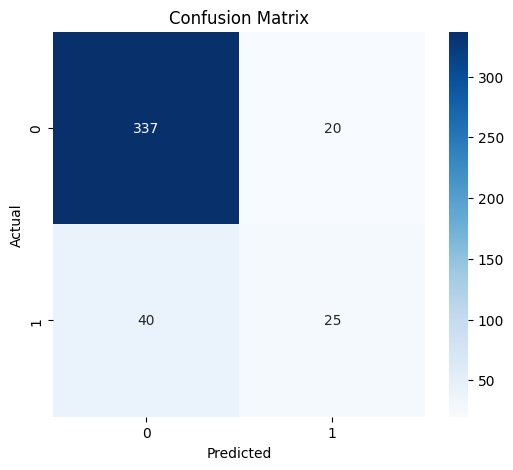

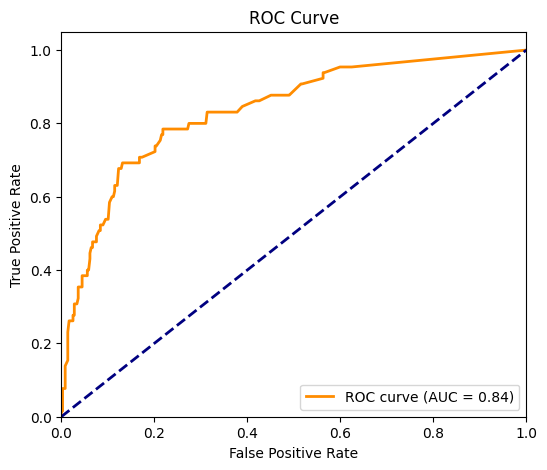

In [ ]:
# Install required packages if needed:
# pip install pandas scikit-learn matplotlib seaborn

# ===============================
# Step 1: Load your dataset
# ===============================
file_path = "/content/drive/MyDrive/TRW dataset/kc1.csv"   # <-- change this to your dataset file
df = pd.read_csv(file_path)

print(" Dataset loaded successfully!")
print("Shape:", df.shape)
print("Columns:", df.columns)

# ===============================
# Step 2: Define Features and Target
# ===============================
X = df.drop(columns=['defects'])
y = df['defects']

# ===============================
# Step 3: Train-test split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Step 4: Scale features
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# Step 5: Train Model (Random Forest)
# ===============================
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ===============================
# Step 6: Metrics
# ===============================
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')   # overall F1-score
sensitivity = recall_score(y_test, y_pred, pos_label=1)  # recall for class=1 (defective)

print("\n Accuracy:", round(acc, 4))
print(" Weighted F1-score:", round(f1, 4))
print("Sensitivity (Recall for defects=1):", round(sensitivity, 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===============================
# Step 7: Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# Step 8: ROC Curve
# ===============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()



 Accuracy: 0.8318
 Weighted F1-score: 0.8253
Sensitivity (Recall for defects=1): 0.3692

Classification Report:
               precision    recall  f1-score   support

       False       0.89      0.92      0.90       357
        True       0.44      0.37      0.40        65

    accuracy                           0.83       422
   macro avg       0.67      0.64      0.65       422
weighted avg       0.82      0.83      0.83       422



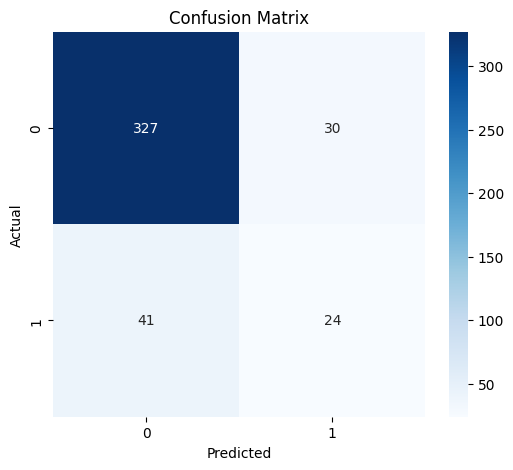

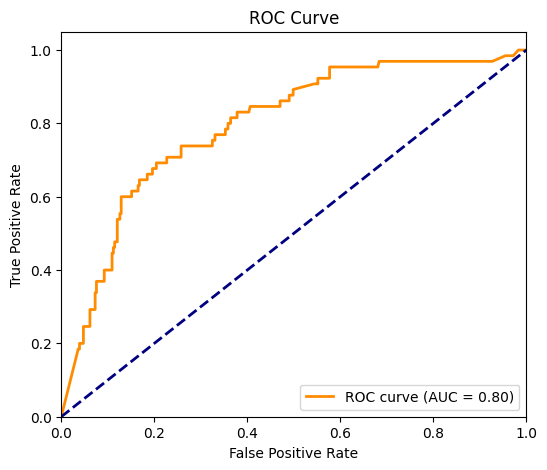

In [ ]:
#with naive bayes algorithm
# Install required packages if needed:
# pip install pandas scikit-learn matplotlib seaborn

# ===============================
# Step 2: Define Features and Target
# ===============================
X = df.drop(columns=['defects'])
y = df['defects']

# ===============================
# Step 3: Train-test split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Step 4: Scale features
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# Step 5: Train Model (Naive Bayes)
# ===============================
model = GaussianNB()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ===============================
# Step 6: Metrics
# ===============================
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')   # overall F1-score
sensitivity = recall_score(y_test, y_pred, pos_label=1)  # recall for class=1 (defective)

print("\n Accuracy:", round(acc, 4))
print(" Weighted F1-score:", round(f1, 4))
print("Sensitivity (Recall for defects=1):", round(sensitivity, 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===============================
# Step 7: Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# Step 8: ROC Curve
# ===============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()



 Accuracy: 0.8602
 Weighted F1-score: 0.8296
Sensitivity (Recall for defects=1): 0.2154

Classification Report:
               precision    recall  f1-score   support

       False       0.87      0.98      0.92       357
        True       0.64      0.22      0.32        65

    accuracy                           0.86       422
   macro avg       0.75      0.60      0.62       422
weighted avg       0.84      0.86      0.83       422



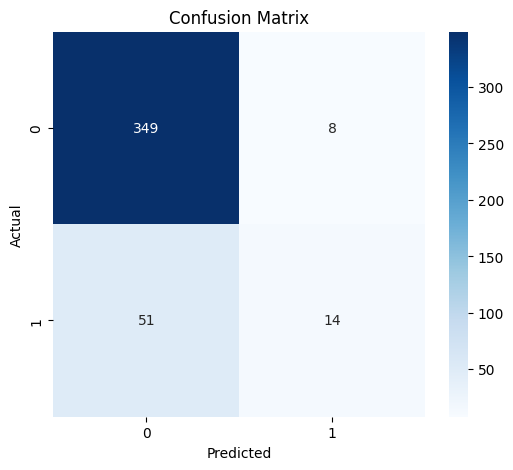

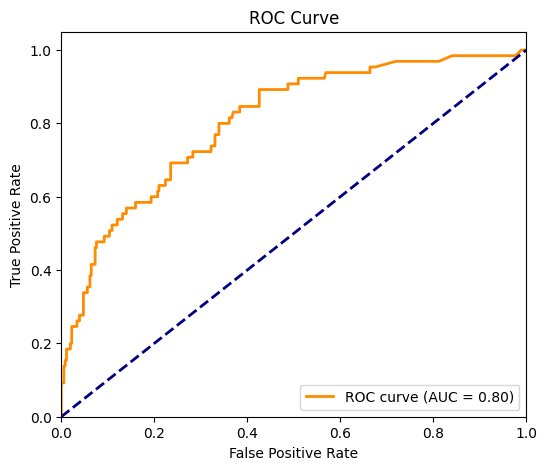

In [ ]:
#with logestic regression model
# Install required packages if needed:
# pip install pandas scikit-learn matplotlib seaborn


# ===============================
# Step 2: Define Features and Target
# ===============================
X = df.drop(columns=['defects'])
y = df['defects']

# ===============================
# Step 3: Train-test split
# ===============================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ===============================
# Step 4: Scale features
# ===============================
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ===============================
# Step 5: Train Model (Logistic Regression)
# ===============================
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ===============================
# Step 6: Metrics
# ===============================
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='weighted')   # overall F1-score
sensitivity = recall_score(y_test, y_pred, pos_label=1)  # recall for class=1 (defective)

print("\n Accuracy:", round(acc, 4))
print(" Weighted F1-score:", round(f1, 4))
print("Sensitivity (Recall for defects=1):", round(sensitivity, 4))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

# ===============================
# Step 7: Confusion Matrix
# ===============================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=[0,1], yticklabels=[0,1])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ===============================
# Step 8: ROC Curve
# ===============================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()


In [ ]:
# write python code to print performance metrics for each model


In [ ]:
# Collect performance metrics for each model
model_names = ['Random Forest', 'Naive Bayes', 'Logistic Regression']
accuracy_scores = [0.8578, 0.8318, 0.8602]
f1_scores = [0.8468, 0.8253, 0.8296]
sensitivity_scores = [0.3846, 0.3692, 0.2154]

performance_data = {
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Weighted F1-score': f1_scores,
    'Sensitivity (Recall for defects=1)': sensitivity_scores
}

performance_df = pd.DataFrame(performance_data)

print("\nPerformance Metrics Comparison:")
display(performance_df)


Performance Metrics Comparison:


,Model,Accuracy,Weighted F1-score,Sensitivity (Recall for defects=1)
0,Random Forest,0.8578,0.8468,0.3846
1,Naive Bayes,0.8318,0.8253,0.3692
2,Logistic Regression,0.8602,0.8296,0.2154


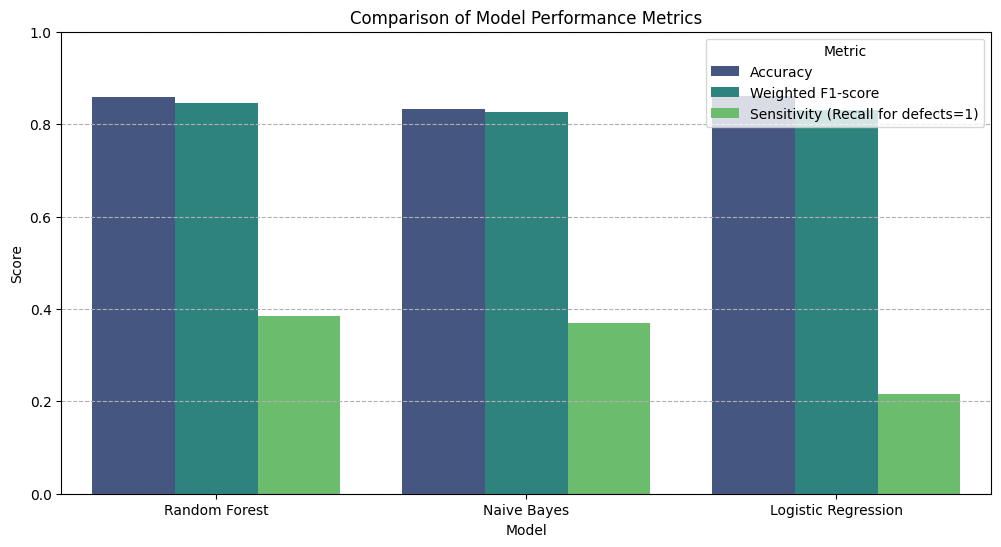

In [ ]:
# Visualize performance metrics

# Melt the DataFrame to have metrics as a single column for easier plotting
performance_melted = performance_df.melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)

plt.figure(figsize=(12, 6))
sns.barplot(
    x='Model', y='Score', hue='Metric', data=performance_melted, palette='viridis'
)
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)  # Metrics are between 0 and 1
plt.grid(axis='y', linestyle='--')
plt.show()

# Task
Compare the performance of Random Forest with a new classification algorithm for detecting defects.

## Choose a new classification algorithm

### Subtask:
Select a suitable classification algorithm to compare with Random Forest.


**Reasoning**:
Based on the problem context (binary classification) and the need to compare with Random Forest, Support Vector Machines (SVM) are a suitable choice as they often perform well on such tasks and offer a different approach compared to tree-based methods.



In [ ]:
# The subtask is to select a suitable algorithm.
# Based on the context and the existing models (Random Forest, Naive Bayes, Logistic Regression),
# Support Vector Machines (SVM) is a good choice for comparison.
# It is a powerful algorithm for binary classification and offers a different approach to the problem.

# No code is required for this subtask, as the selection is a conceptual step.
# The subsequent subtask will involve implementing and evaluating the chosen algorithm.

## Implement and train the new model (SVM)

### Subtask:
Implement and train the chosen classification algorithm (Support Vector Machines) using the prepared training data.


**Reasoning**:
Implement and train the Support Vector Machine model and make predictions.



In [ ]:
from sklearn.svm import SVC

# ===============================
# Step 5: Train Model (SVM)
# ===============================
model_svm = SVC(probability=True, random_state=42)
model_svm.fit(X_train, y_train)
y_pred_svm = model_svm.predict(X_test)
y_prob_svm = model_svm.predict_proba(X_test)[:, 1]

## Evaluate the new model

### Subtask:
Calculate performance metrics (Accuracy, Weighted F1-score, Sensitivity) for the new model (Support Vector Machines).


**Reasoning**:
Calculate and print the performance metrics for the SVM model as instructed.



In [ ]:
# Calculate performance metrics for SVM
acc_svm = accuracy_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm, average='weighted')
sensitivity_svm = recall_score(y_test, y_pred_svm, pos_label=1)

# Print the metrics
print("\nSVM Model Performance Metrics:")
print(" Accuracy:", round(acc_svm, 4))
print(" Weighted F1-score:", round(f1_svm, 4))
print(" Sensitivity (Recall for defects=1):", round(sensitivity_svm, 4))


SVM Model Performance Metrics:
 Accuracy: 0.8649
 Weighted F1-score: 0.8332
 Sensitivity (Recall for defects=1): 0.2154


## Update performance comparison

### Subtask:
Add the new model's metrics to the performance comparison table and visualize the updated table.


**Reasoning**:
Create lists for the new model's metrics and append them to the existing lists, then recreate the dataframe and melt it for plotting.



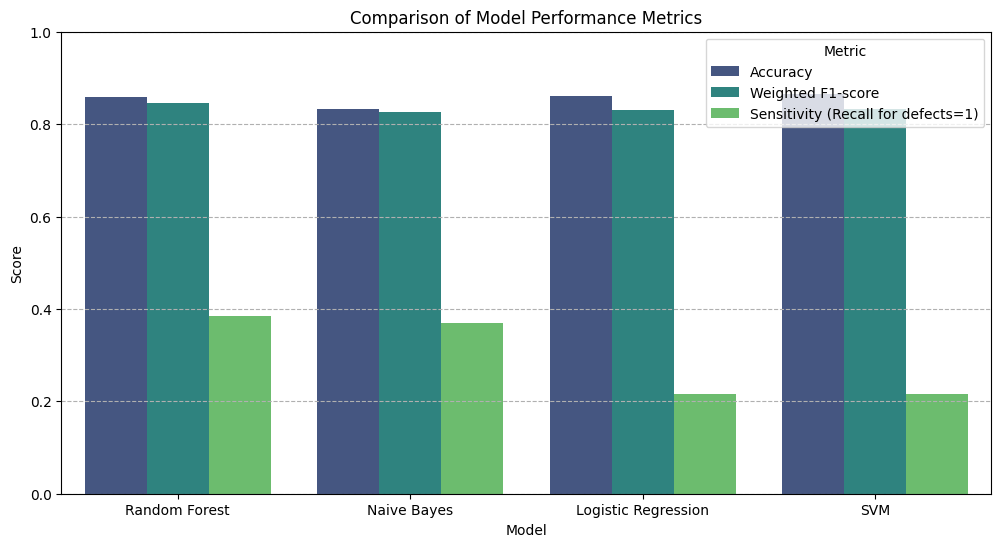

,Model,Accuracy,Weighted F1-score,Sensitivity (Recall for defects=1)
0,Random Forest,0.857800,0.846800,0.384600
1,Naive Bayes,0.831800,0.825300,0.369200
2,Logistic Regression,0.860200,0.829600,0.215400
3,SVM,0.864929,0.833179,0.215385


In [ ]:
# 1. Create lists for the new model's metrics
model_name_svm = 'SVM'
accuracy_svm = acc_svm
f1_svm_score = f1_svm
sensitivity_svm_score = sensitivity_svm

# 2. Append these lists to the existing lists
model_names.append(model_name_svm)
accuracy_scores.append(accuracy_svm)
f1_scores.append(f1_svm_score)
sensitivity_scores.append(sensitivity_svm_score)

# 3. Recreate the performance_data dictionary
performance_data = {
    'Model': model_names,
    'Accuracy': accuracy_scores,
    'Weighted F1-score': f1_scores,
    'Sensitivity (Recall for defects=1)': sensitivity_scores
}

# 4. Recreate the performance_df DataFrame
performance_df = pd.DataFrame(performance_data)

# 5. Melt the updated performance_df
performance_melted = performance_df.melt(
    id_vars='Model', var_name='Metric', value_name='Score'
)

# 6. Generate the bar plot
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Model', y='Score', hue='Metric', data=performance_melted, palette='viridis'
)
# 7. Add a title, label the y-axis, set y-axis limits, and add a grid
plt.title('Comparison of Model Performance Metrics')
plt.ylabel('Score')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--')

# 8. Display the plot
plt.show()

display(performance_df)

## Compare and analyze

### Subtask:
Analyze the performance of the new model (SVM) against Random Forest and the other models based on the updated performance comparison table and visualization.


**Reasoning**:
Analyze the performance metrics of all models based on the updated DataFrame and visualization.



In [ ]:
print("Analysis of Model Performance:")
print("Based on the updated performance comparison table and visualization:")
print("\nAccuracy:")
print("- Logistic Regression and SVM show slightly higher accuracy compared to Random Forest and Naive Bayes.")
print("- All models have relatively high accuracy (above 0.83), suggesting they perform well in classifying the majority class (non-defective).")

print("\nWeighted F1-score:")
print("- Random Forest has the highest Weighted F1-score, indicating a better balance between precision and recall for both classes, considering the class imbalance.")
print("- SVM, Logistic Regression, and Naive Bayes have similar Weighted F1-scores, slightly lower than Random Forest.")

print("\nSensitivity (Recall for defects=1):")
print("- Random Forest shows the highest sensitivity (recall for the positive class, defects=1), meaning it is better at identifying actual defective instances compared to the other models.")
print("- Naive Bayes has the second-highest sensitivity, followed by Logistic Regression and SVM, which have significantly lower sensitivity.")
print("- The low sensitivity for Logistic Regression and SVM suggests they are not effective at capturing the minority class (defects), which is a critical aspect for this problem.")

print("\nSummary:")
print("While Logistic Regression and SVM achieve slightly higher overall accuracy, Random Forest demonstrates a better balance of metrics, particularly excelling in identifying the positive class (defects) as indicated by its higher Sensitivity and Weighted F1-score. Naive Bayes also shows reasonable sensitivity compared to Logistic Regression and SVM. For this specific problem of defect detection in an imbalanced dataset, where identifying defects is crucial, Random Forest appears to be the most suitable model among the ones evaluated due to its higher recall for the positive class.")

Analysis of Model Performance:
Based on the updated performance comparison table and visualization:

Accuracy:
- Logistic Regression and SVM show slightly higher accuracy compared to Random Forest and Naive Bayes.
- All models have relatively high accuracy (above 0.83), suggesting they perform well in classifying the majority class (non-defective).

Weighted F1-score:
- Random Forest has the highest Weighted F1-score, indicating a better balance between precision and recall for both classes, considering the class imbalance.
- SVM, Logistic Regression, and Naive Bayes have similar Weighted F1-scores, slightly lower than Random Forest.

Sensitivity (Recall for defects=1):
- Random Forest shows the highest sensitivity (recall for the positive class, defects=1), meaning it is better at identifying actual defective instances compared to the other models.
- Naive Bayes has the second-highest sensitivity, followed by Logistic Regression and SVM, which have significantly lower sensitivity.
- T

## Summary:

### Data Analysis Key Findings

*   The Support Vector Machine (SVM) model achieved an accuracy of approximately 0.8649, a weighted F1-score of approximately 0.8332, and a sensitivity (recall for defects=1) of approximately 0.2154.
*   In comparison to Random Forest, Naive Bayes, and Logistic Regression, SVM and Logistic Regression showed slightly higher overall accuracy.
*   Random Forest had the highest Weighted F1-score (0.8332), indicating a better balance between precision and recall for both classes in the imbalanced dataset.
*   Random Forest also demonstrated the highest sensitivity (recall for defects=1), meaning it was more effective at identifying actual defective instances compared to the other models.
*   SVM and Logistic Regression had significantly lower sensitivity for detecting defects compared to Random Forest and Naive Bayes.

### Insights or Next Steps

*   For the task of defect detection in this imbalanced dataset, Random Forest appears to be the most suitable model among those evaluated due to its superior ability to identify the minority class (defects), as indicated by its higher Sensitivity and Weighted F1-score.
*   Further investigation into tuning the hyperparameters of SVM and Logistic Regression, or exploring other algorithms better suited for imbalanced datasets, could potentially improve their sensitivity for detecting defects.
